/var/folders/nj/jy9kb34503nb3927j498k11m0000gn/T/ipykernel_26719/4015839466.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m1 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 30))
/var/folders/nj/jy9kb34503nb3927j498k11m0000gn/T/ipykernel_26719/4015839466.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m3 = pairs.groupby("date", group_keys=False).apply(lambda g: select_targ

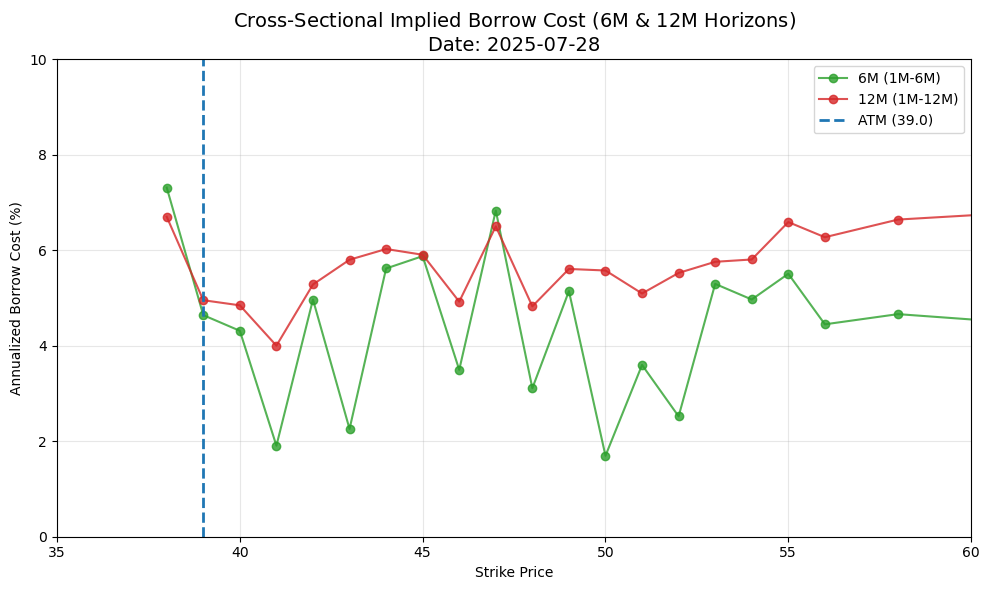

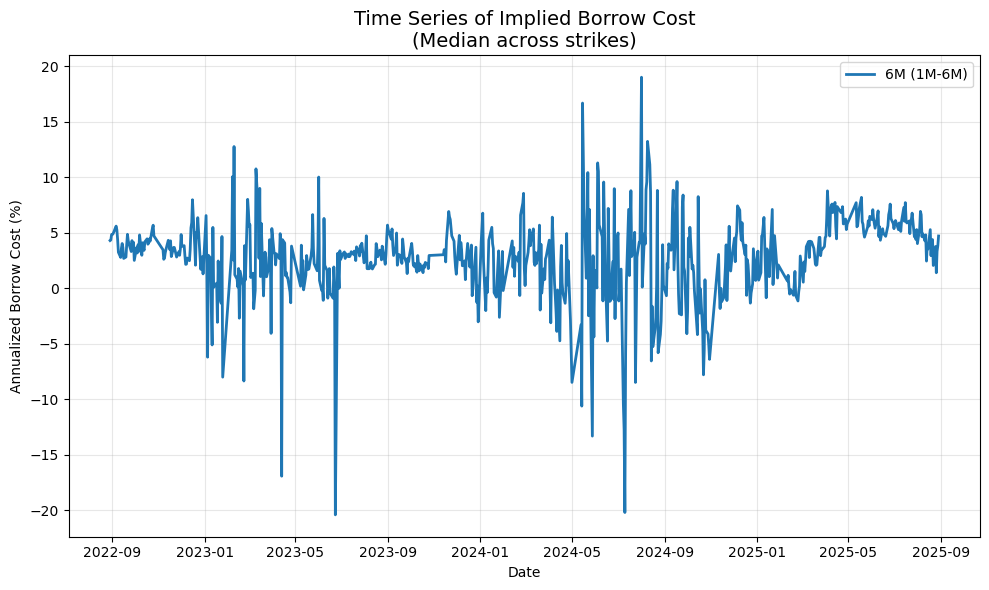

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(df):
    """Standardize columns and clean initial data."""
    df.columns = [c.lower().strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"])
    df["exdate"] = pd.to_datetime(df["exdate"])
    
    # Handle Strike Price scaling
    if df["strike_price"].max() > 5000:
        df["strike"] = df["strike_price"] / 1000.0
    else:
        df["strike"] = df["strike_price"]
        
    df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0
    return df[(df["best_bid"] > 0) & (df["best_offer"] > df["best_bid"])].copy()

def select_target_expiry(group, target_days, tolerance=40):
    """Finds the best expiry for a given target maturity."""
    unique_expiries = group[["exdate", "days_to_expiry"]].drop_duplicates().copy()
    unique_expiries["diff"] = (unique_expiries["days_to_expiry"] - target_days).abs()
    
    best_row = unique_expiries.sort_values("diff").iloc[0]
    if best_row["diff"] <= tolerance:
        return group[group["exdate"] == best_row["exdate"]]
    return pd.DataFrame()

def run_triple_analysis(options_df, r=0.045):
    # 1. Setup Pairs and calculate 'A'
    df = prepare_data(options_df)
    calls = df[df["cp_flag"] == "C"][["date", "exdate", "strike", "mid"]].rename(columns={"mid": "c_mid"})
    puts = df[df["cp_flag"] == "P"][["date", "exdate", "strike", "mid"]].rename(columns={"mid": "p_mid"})
    pairs = pd.merge(calls, puts, on=["date", "exdate", "strike"])
    
    pairs["days_to_expiry"] = (pairs["exdate"] - pairs["date"]).dt.days
    pairs["T"] = pairs["days_to_expiry"] / 365.0
    pairs["A"] = pairs["c_mid"] - pairs["p_mid"] + pairs["strike"] * np.exp(-r * pairs["T"])
    pairs = pairs[pairs["A"] > 0].copy()

    # 2. Extract specific horizons
    m1 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 30))
    m3 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 91))
    m6 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 182))
    m12 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 365))

    def get_bc_df(m_base, m_target):
        merged = pd.merge(m_base, m_target, on=["date", "strike"], suffixes=("_1", "_2"))
        merged["bc"] = (np.log(merged["A_1"]) - np.log(merged["A_2"])) / (merged["T_2"] - merged["T_1"])
        merged["bc_pct"] = merged["bc"] * 100
        # Filter outliers to keep plots readable (adjust as needed)
        return merged[merged["bc_pct"].between(-30, 30)].copy()

    # 3. Calculate the three separate dataframes
    s3 = get_bc_df(m1, m3)
    s6 = get_bc_df(m1, m6)
    s12 = get_bc_df(m1, m12)
    
    return s3, s6, s12

def plot_triple_results(s3, s6, s12, df, r=0.045):
    # Identify the latest common date
    common_dates = set(s3['date']) & set(s6['date']) & set(s12['date'])
    latest_date = max(common_dates)

    # --- FIGURE 1: CROSS-SECTIONAL IMPLIED BORROW COST ---
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    data_list = [(s6, "6M (1M-6M)", "tab:green"), 
                 (s12, "12M (1M-12M)", "tab:red")]

    # Calculate ATM using forward estimation method
    df_latest = df[df["date"] == latest_date].copy()
    atm_strike = None
    if len(df_latest) > 0:
        # Recalculate A values for this date
        calls = df_latest[df_latest["cp_flag"] == "C"][["exdate", "strike", "mid"]].rename(columns={"mid": "c_mid"})
        puts = df_latest[df_latest["cp_flag"] == "P"][["exdate", "strike", "mid"]].rename(columns={"mid": "p_mid"})
        pairs_date = pd.merge(calls, puts, on=["exdate", "strike"])
        
        pairs_date["days_to_expiry"] = (pd.to_datetime(pairs_date["exdate"]) - pd.to_datetime(latest_date)).dt.days
        pairs_date["T"] = pairs_date["days_to_expiry"] / 365.0
        pairs_date["A"] = pairs_date["c_mid"] - pairs_date["p_mid"] + pairs_date["strike"] * np.exp(-r * pairs_date["T"])
        pairs_date = pairs_date[pairs_date["A"] > 0].copy()
        
        if len(pairs_date) > 0:
            # Use middle strikes (30th-70th percentile) for more robust forward estimation
            mid_strikes = pairs_date[
                pairs_date["strike"].between(
                    pairs_date["strike"].quantile(0.3),
                    pairs_date["strike"].quantile(0.7)
                )
            ]
            
            if len(mid_strikes) > 0:
                F_est = mid_strikes["A"].median()
                
                # Then find closest strike to that forward
                pairs_date["fwd_diff"] = (pairs_date["strike"] - F_est).abs()
                atm_strike = pairs_date.loc[pairs_date["fwd_diff"].idxmin(), "strike"]
    

    for df_plot, label, color in data_list:
        day_data = df_plot[df_plot["date"] == latest_date].sort_values("strike")
        ax1.plot(day_data["strike"], day_data["bc_pct"], marker='o', label=label, color=color, alpha=0.8)

    # Add ATM vertical line if available
    if atm_strike is not None:
        ax1.axvline(x=atm_strike, linestyle='--', linewidth=2, label=f'ATM ({atm_strike:.1f})')

    ax1.set_title(f"Cross-Sectional Implied Borrow Cost (6M $&$ 12M Horizons)\nDate: {latest_date.date()}", fontsize=14)
    ax1.set_xlabel("Strike Price")
    ax1.set_ylabel("Annualized Borrow Cost (%)")
    ax1.set_ylim(0, 10)
    ax1.set_xlim(35, 60)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    fig1.tight_layout()
    fig1.savefig("cross_section_2lines.png", dpi=300, bbox_inches="tight")
    plt.show()

    # --- FIGURE 2: TERM STRUCTURE OVER TIME ---
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    # Only show 6M line for time evolution
    time_data_list = [(s6, "6M (1M-6M)", "tab:green")]
    
    for df_plot, label, color in time_data_list:
        ts = df_plot.groupby("date")["bc_pct"].median()
        ax2.plot(ts.index, ts.values, label=label, linewidth=2)

    ax2.set_title("Time Series of Implied Borrow Cost\n(Median across strikes)", fontsize=14)
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Annualized Borrow Cost (%)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    fig2.tight_layout()
    fig2.savefig("term_structure_6M.png", dpi=300, bbox_inches="tight")
    plt.show()

# Execution
df = pd.read_csv("b10xheebr3v3h1vn.csv", low_memory=False)
s3, s6, s12 = run_triple_analysis(df)
plot_triple_results(s3, s6, s12, df)

In [21]:
# Print values used to calculate implied borrow cost
print("\n=== Values for Implied Borrow Cost Calculation (6-Month Spread, first 30 rows) ===")
print(s6[['date', 'strike', 'A_1', 'A_2', 'T_1', 'T_2', 'bc_pct']].head(20))


=== Values for Implied Borrow Cost Calculation (6-Month Spread, first 30 rows) ===
         date  strike        A_1        A_2       T_1       T_2    bc_pct
0  2022-08-29    12.0  14.527751  14.107728  0.087671  0.547945  6.374020
1  2022-08-29    13.0  14.423813  14.158372  0.087671  0.547945  4.035522
2  2022-08-29    14.0  14.569876  14.209016  0.087671  0.547945  5.448805
3  2022-08-29    15.0  14.615938  14.234660  0.087671  0.547945  5.742840
4  2022-08-29    16.0  14.512001  14.210304  0.087671  0.547945  4.564380
5  2022-08-29    17.0  14.433064  14.185948  0.087671  0.547945  3.752067
6  2022-08-29    18.0  14.454126  14.236592  0.087671  0.547945  3.294646
7  2022-08-29    19.0  14.475189  14.137236  0.087671  0.547945  5.132579
8  2022-08-29    20.0  14.371251  14.187880  0.087671  0.547945  2.790018
9  2022-08-29    21.0  14.542314  14.113524  0.087671  0.547945  6.502463
10 2022-08-29    22.0  14.538376  14.164168  0.087671  0.547945  5.665418
11 2022-08-29    23.0  14.35